In [ ]:
%%capture
%cd ../..

In [31]:
import psycopg
import pandas as pd
import numpy as np

In [57]:
conn = psycopg.connect('postgresql://USER@localhost:5432/mlflow_db')

In [58]:
def decode_if_bytes(x):
    if isinstance(x, bytes):
        return x.decode("utf-8")
    return x

In [59]:
def execute_query(query, conn, limit=None):
    if limit:
        query += f" LIMIT {limit};"
    with conn.cursor() as cursor:
        cursor.execute(query)
        return cursor.fetchall()

In [60]:
earliest_query = """SELECT
    p.value AS expression,
    COALESCE(MIN(m.step)::text, 'does not exist') AS first_step
FROM runs r
JOIN experiments e
    ON r.experiment_id = e.experiment_id
JOIN params p
    ON r.run_uuid = p.run_uuid
   AND p.key = 'expression'
LEFT JOIN metrics m
    ON r.run_uuid = m.run_uuid
   AND m.key = 'val_loss_running_avg50'
   AND m.value < 0.05
WHERE e.name = 'transformers_improved_2'
GROUP BY
    p.value
ORDER BY
    p.value
"""

In [61]:
earliest_step_result = execute_query(query=earliest_query, conn=conn)

In [62]:
df = pd.DataFrame(earliest_step_result, columns=['expression', 'first_step'])
df["expression"] = df["expression"].apply(decode_if_bytes)
df["first_step"] = df["first_step"].apply(decode_if_bytes)

In [63]:
no_training_query = """SELECT DISTINCT pexp.value AS expression
FROM runs r
JOIN params pexp
  ON r.run_uuid = pexp.run_uuid
  AND pexp.key = 'expression'
LEFT JOIN metrics m
  ON r.run_uuid = m.run_uuid
  AND m.key = 'val_loss_running_avg50'
WHERE m.run_uuid IS NULL
ORDER BY pexp.value;
"""

In [92]:
no_training_df['expression'].tolist()

['and(and(not(subset_eq(A, B)), equals(cardinality(A), cardinality(B))), subset_eq(B, index(cardinality(A), union(A, B))))',
 'and(and(not(subset_eq(B, A)), subset_eq(A, difference(A, B))), subset_eq(A, index(cardinality(A), union(A, B))))',
 'and(and(subset_eq(A, difference(A, B)), equals(cardinality(A), cardinality(B))), subset_eq(index(cardinality(A), union(A, B)), A))',
 'and(and(subset_eq(A, difference(A, B)), greater_than(cardinality(A), cardinality(B))), subset_eq(B, index(cardinality(B), union(A, B))))',
 'and(and(subset_eq(A, difference(A, B)), greater_than(cardinality(A), cardinality(B))), subset_eq(index(cardinality(A), union(A, B)), A))',
 'and(and(subset_eq(A, difference(A, B)), greater_than(cardinality(B), cardinality(A))), subset_eq(index(cardinality(B), union(A, B)), B))',
 'and(greater_than(cardinality(A), cardinality(B)), subset_eq(B, index(cardinality(B), union(A, B))))',
 'and(greater_than(cardinality(B), cardinality(A)), subset_eq(A, index(cardinality(A), union(A, 

In [101]:
df.loc[df['expression'] == 'subset_eq(union(difference(A, B), index(cardinality(A), B)), index(cardinality(difference(A, B)), union(difference(A, B), difference(B, A))))']

,expression,first_step,no_training
1755,"subset_eq(union(difference(A, B), index(cardin...",does not exist,True


In [100]:
for expression in no_training_df['expression'].tolist():
    if df.loc[df['expression'] == expression]['no_training'].values[0]:
        print(df[df['expression'] == expression])

                                          expression      first_step  \
0  and(and(not(subset_eq(A, B)), equals(cardinali...  does not exist   

   no_training  
0         True  
                                           expression      first_step  \
12  and(and(not(subset_eq(B, A)), subset_eq(A, dif...  does not exist   

    no_training  
12         True  
                                           expression      first_step  \
15  and(and(subset_eq(A, difference(A, B)), equals...  does not exist   

    no_training  
15         True  
                                           expression      first_step  \
16  and(and(subset_eq(A, difference(A, B)), greate...  does not exist   

    no_training  
16         True  
                                           expression      first_step  \
17  and(and(subset_eq(A, difference(A, B)), greate...  does not exist   

    no_training  
17         True  
                                           expression      first_step  \
18  and(and(subs

IndexError: index 0 is out of bounds for axis 0 with size 0

In [96]:
df[df["expression"]=='and(or(subset_eq(A, difference(A, B)), equals(cardinality(A), cardinality(B))), subset_eq(difference(A, B), index(cardinality(A), union(A, B))))']

,expression,first_step,no_training
245,"and(or(subset_eq(A, difference(A, B)), equals(...",does not exist,True


In [64]:
no_training_result = execute_query(query=no_training_query, conn=conn)
no_training_df = pd.DataFrame(no_training_result)
no_training_df = no_training_df.applymap(decode_if_bytes)
no_training_df.columns = ['expression']

df["no_training"] = df["expression"].isin(no_training_df["expression"])

/var/folders/ww/zmy65s114cv2_jtlds20mdzc0000gn/T/ipykernel_59825/3076025092.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.


In [85]:
no_training_df["expression"].iloc[-50:].tolist()

['subset_eq(index(cardinality(difference(A, B)), union(A, B)), difference(union(A, B), index(cardinality(A), B)))',
 'subset_eq(intersection(A, B), index(cardinality(A), union(A, B)))',
 'subset_eq(intersection(A, B), index(cardinality(B), A))',
 'subset_eq(intersection(A, B), index(cardinality(B), union(A, B)))',
 'subset_eq(union(A, B), difference(A, A))',
 'subset_eq(union(A, B), index(cardinality(A), B))',
 'subset_eq(union(A, B), index(cardinality(B), A))',
 'subset_eq(union(A, B), index(cardinality(intersection(A, B)), union(A, B)))',
 'subset_eq(union(A, index(cardinality(A), B)), difference(difference(A, B), index(cardinality(B), union(A, B))))',
 'subset_eq(union(A, index(cardinality(A), B)), index(cardinality(A), union(A, B)))',
 'subset_eq(union(A, index(cardinality(A), difference(B, A))), index(cardinality(A), B))',
 'subset_eq(union(A, index(cardinality(A), difference(B, A))), index(cardinality(difference(A, A)), A))',
 'subset_eq(union(A, index(cardinality(A), difference(

In [89]:
df.loc[df['expression'] == "not(greater_than(cardinality(A), cardinality(B)))"]

,expression,first_step,no_training
505,"not(greater_than(cardinality(A), cardinality(B)))",892,True


In [65]:
mono_query = """SELECT DISTINCT pexp.value AS expression,
       m.value AS monotonicity_entropic
FROM runs r
JOIN params pexp
  ON r.run_uuid = pexp.run_uuid
  AND pexp.key = 'expression'
JOIN metrics m
  ON r.run_uuid = m.run_uuid
  AND m.key = 'monotonicity_entropic'
ORDER BY expression;"""

In [66]:
monotonicity_results = execute_query(query=mono_query, conn=conn)
mono_df = pd.DataFrame(monotonicity_results)
mono_df = mono_df.applymap(decode_if_bytes)
mono_df.columns = ['expression', 'monotonicity_entropic']

/var/folders/ww/zmy65s114cv2_jtlds20mdzc0000gn/T/ipykernel_59825/1877062125.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.


In [67]:
depth_query = """SELECT DISTINCT pexp.value AS expression,
       pdepth.value AS expression_depth
FROM runs r
JOIN params pexp
  ON r.run_uuid = pexp.run_uuid
  AND pexp.key = 'expression'
JOIN params pdepth
  ON r.run_uuid = pdepth.run_uuid
  AND pdepth.key = 'expression_depth'
ORDER BY expression;"""

In [68]:
depth_results = execute_query(query=depth_query, conn=conn)
depth_df = pd.DataFrame(depth_results)
depth_df = depth_df.applymap(decode_if_bytes)
depth_df.columns = ['expression', 'expression_depth']
depth_df['expression_depth'].value_counts()

/var/folders/ww/zmy65s114cv2_jtlds20mdzc0000gn/T/ipykernel_59825/3345850333.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.


expression_depth
4    1868
3     122
2      11
1       3
Name: count, dtype: int64

In [77]:
final_df

,expression,first_step,no_training,monotonicity_entropic,expression_depth
0,"and(and(not(subset_eq(A, B)), equals(cardinali...",<NA>,True,1.000000,4
1,"and(and(not(subset_eq(A, B)), equals(cardinali...",<NA>,False,0.084976,4
2,"and(and(not(subset_eq(A, B)), greater_than(car...",<NA>,False,0.358207,4
3,"and(and(not(subset_eq(A, B)), greater_than(car...",<NA>,False,0.421155,4
4,"and(and(not(subset_eq(A, B)), greater_than(car...",<NA>,False,0.328792,4
...,...,...,...,...,...
1995,"subset_eq(union(intersection(A, B), index(card...",<NA>,True,0.216523,4
1996,"subset_eq(union(intersection(A, B), index(card...",<NA>,True,0.048894,4
1997,"subset_eq(union(intersection(A, B), index(card...",<NA>,True,0.000000,4
1998,"subset_eq(union(intersection(A, B), index(card...",<NA>,False,0.300023,4


In [76]:
final_df = df.merge(mono_df, on='expression').merge(depth_df, on='expression')
final_df["first_step"] = final_df["first_step"].replace("does not exist", np.nan)
final_df["first_step"] = final_df["first_step"].astype("Int64")

In [78]:
final_df.to_csv('../analysis/transformers_improved_2.csv', index=False)

plotnine/ggplot.py:587: PlotnineWarning: Saving 6.4 x 4.8 in image.
plotnine/ggplot.py:588: PlotnineWarning: Filename: monotonicity_vs_training_step.png


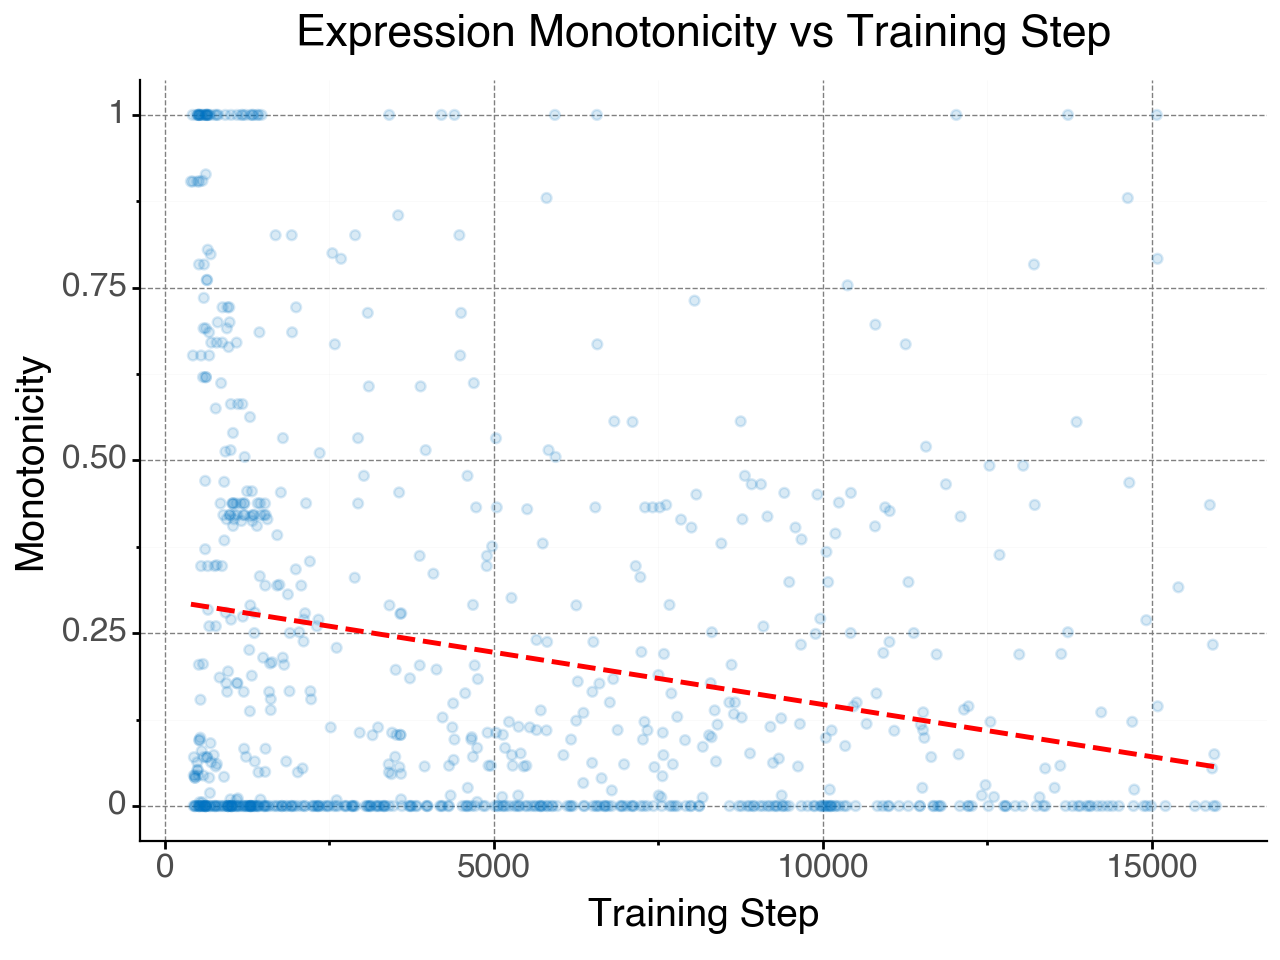

<Figure Size: (640 x 480)>

In [37]:
# Creating the plot
from plotnine import element_line, stat_smooth, annotate

plotdf = trained.copy()

# Replace "does not exist" (if present) with NaN in both columns
plotdf["first_step"] = plotdf["first_step"].replace("does not exist", np.nan)
plotdf["first_step"] = plotdf["first_step"].astype(float)
plotdf["monotonicity_entropic"] = plotdf["monotonicity_entropic"].replace("does not exist", np.nan)

# Convert to numeric (this will turn valid strings like "2648" into 2648.0)
plotdf["first_step"] = pd.to_numeric(plotdf["first_step"], errors="coerce")
plotdf["monotonicity_entropic"] = pd.to_numeric(plotdf["monotonicity_entropic"], errors="coerce")

# Drop rows where either is NaN
plotdf.dropna(subset=["first_step", "monotonicity_entropic"], inplace=True)

plot = (
    ggplot(plotdf, aes(y='monotonicity_entropic', x='first_step')) +
    geom_point(alpha=0.15, color='#0073C2') +
    theme_minimal() +
    stat_smooth(method='lm', color='red', linetype='dashed', se=False) +  # Add line of best fit (linear model)
    theme(
        plot_background=element_rect(fill="white", color="white"),  # White background
        panel_background=element_rect(fill="white", color="white"),   # White panel
        panel_grid_major=element_line(color="gray", size=0.5, linetype='dashed'),  # Dashed grid lines
        panel_grid_minor=element_line(color="lightgray", size=0.25, alpha=0.15),  # Minor grid lines
        plot_title=element_text(ha='center', size=16, weight='bold'),  # Bold, centered title
        axis_title=element_text(size=14, weight='bold'),  # Bold axis titles
        axis_text=element_text(size=12),  # Adjust axis text size
        axis_line=element_line(color="black", size=0.8),  # Add strong axis lines
        axis_ticks=element_line(color="black"),  # Add clean ticks
        legend_position="right"
    ) +
    labs(title='Expression Monotonicity vs Training Step',
         y='Monotonicity',
         x='Training Step',
         color='Legend')
         
    #annotate('text', x=0.2, y=0.3, label="linear fit", size=10, color="red")  # Line formula annotation
)
plot.save("monotonicity_vs_training_step.png", dpi=300,)  # Save as PNG with 300 DPI
plot

In [38]:
from scipy.stats import spearmanr, pearsonr

# Perform Spearman and Pearson correlation tests
spearman_corr, spearman_pval = spearmanr(plotdf["monotonicity_entropic"], plotdf["first_step"])
pearson_corr, pearson_pval = pearsonr(plotdf["monotonicity_entropic"], plotdf["first_step"])

# Display the results
{
    "Spearman Correlation": spearman_corr,
    "Spearman P-Value": spearman_pval,
    "Pearson Correlation": pearson_corr,
    "Pearson P-Value": pearson_pval
}

{'Spearman Correlation': -0.21504955027408768,
 'Spearman P-Value': 1.4668971701718263e-09,
 'Pearson Correlation': -0.22187706331293577,
 'Pearson P-Value': 4.242738058494252e-10}

In [51]:
plotdf["monotonicity_4sig"] = plotdf["monotonicity_entropic"].apply(
    lambda x: float(f"{x:.4g}")
)
plotdf_X = plotdf[plotdf['monotonicity_4sig'] != 1].sample(n=plotdf['monotonicity_4sig'].value_counts()[1])
plotdf_1 = plotdf[plotdf['monotonicity_4sig'] == 1]
plotdf_01 = pd.concat([plotdf_X, plotdf_1])
plotdf_01["is_monotonicity_1"] = plotdf_01["monotonicity_4sig"] == 1

In [52]:
plotdf_01

,expression,first_step,no_training,monotonicity_entropic,expression_depth,monotonicity_4sig,is_monotonicity_1
1643,"subset_eq(index(cardinality(intersection(A, B)...",6761.0,False,0.149899,4,0.14990,False
581,"or(and(subset_eq(A, difference(A, B)), equals(...",5169.0,False,0.084085,4,0.08409,False
136,"and(not(subset_eq(B, difference(A, A))), subse...",4474.0,False,0.825935,4,0.82590,False
384,"and(subset_eq(index(cardinality(A), union(A, B...",5800.0,False,0.879765,4,0.87980,False
113,"and(not(subset_eq(B, A)), greater_than(cardina...",3082.0,False,0.713543,4,0.71350,False
...,...,...,...,...,...,...,...
1350,"subset_eq(index(cardinality(B), difference(A, ...",4202.0,False,1.000000,3,1.00000,True
1412,"subset_eq(index(cardinality(difference(A, A)),...",647.0,False,1.000000,4,1.00000,True
1413,"subset_eq(index(cardinality(difference(A, A)),...",615.0,False,1.000000,4,1.00000,True
1545,"subset_eq(index(cardinality(difference(B, A)),...",6565.0,False,1.000000,4,1.00000,True


plotnine/ggplot.py:587: PlotnineWarning: Saving 6.4 x 4.8 in image.
plotnine/ggplot.py:588: PlotnineWarning: Filename: monotonicity_distribution_density.png


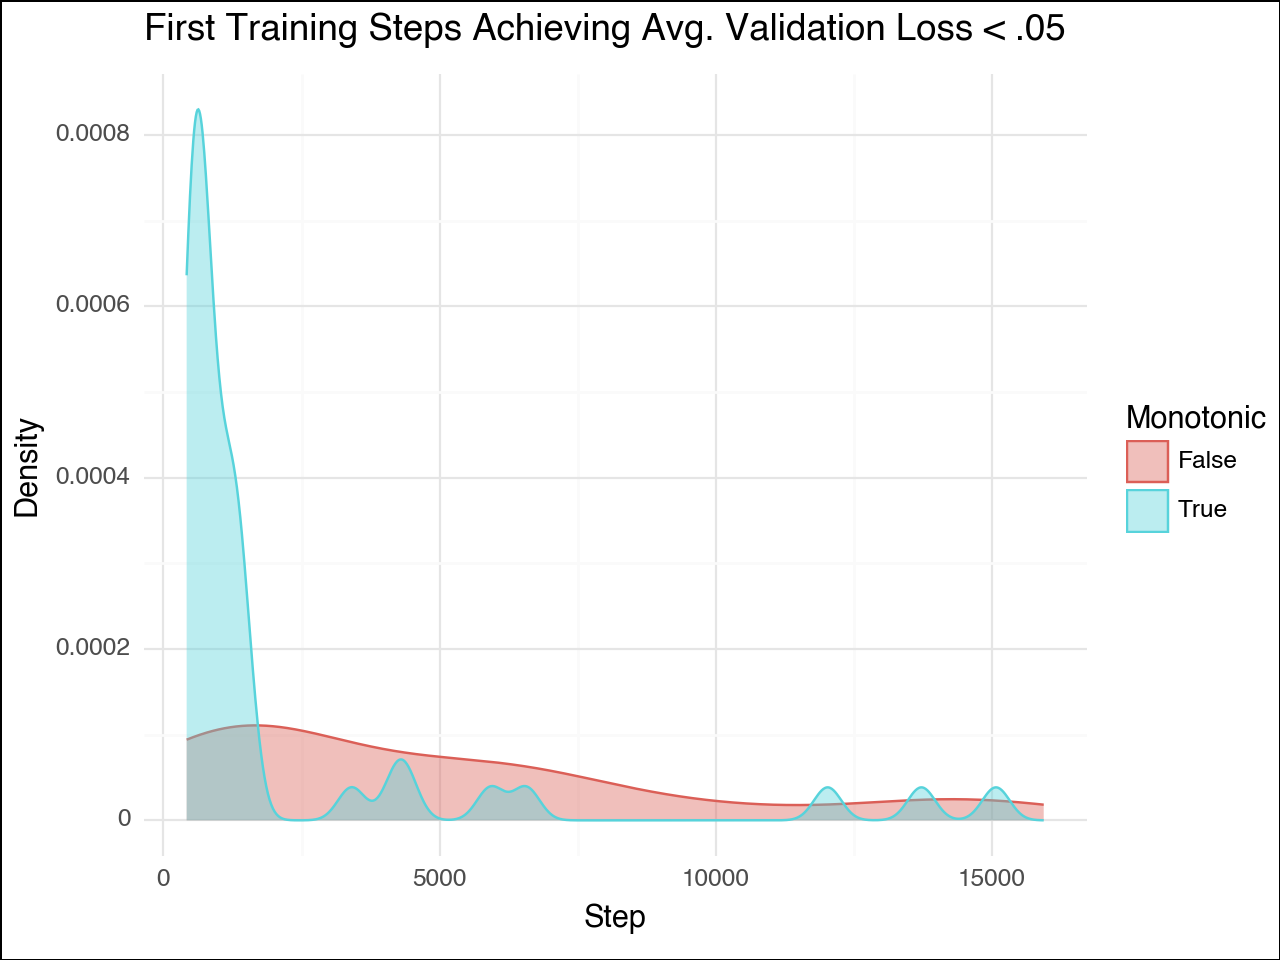

<Figure Size: (640 x 480)>

In [53]:
import numpy as np
import pandas as pd
from plotnine import (
    ggplot, aes, geom_density, labs, theme_minimal, facet_wrap, element_blank,
    scale_fill_manual, scale_color_manual
)

# Convert monotonicity to a string/factor for coloring
plotdf_01["monotonicity_4sig"] = plotdf_01["monotonicity_4sig"].astype(str)

from plotnine import (
    ggplot, aes, geom_density, theme, labs, theme_minimal, element_blank,
)

# Subset to monotonicity = 0 or 1 only
#plotdf_01 = plotdf[plotdf["monotonicity_4sig"].isin([0, 1])].copy()

# Convert monotonicity to a string/factor for coloring
plotdf_01["is_monotonicity_1"] = plotdf_01["is_monotonicity_1"].astype(str)

plot = (
    ggplot(plotdf_01, aes(x="first_step", 
                          color="is_monotonicity_1", 
                          fill="is_monotonicity_1"))
    + geom_density(alpha=0.4)  # semi-transparent so they overlap visibly
    + theme_minimal()
    + theme(
        panel_border=element_blank(),
        panel_background=element_rect(fill="white"),
        plot_background=element_rect(fill="white")
    )
    + labs(
        title="First Training Steps Achieving Avg. Validation Loss < .05",
        x="Step",
        y="Density",
        color="Monotonic",
        fill="Monotonic"
    )
    # Optional custom color/fill if you want specific colors:
    # + scale_color_manual(values=["#0073C2", "red"])
    # + scale_fill_manual(values=["#0073C2", "red"])
)
plot.save("monotonicity_distribution_density.png", dpi=300, transparent=False)
plot


In [54]:
plotdf_01["is_monotonicity_1"].value_counts()

is_monotonicity_1
False    42
True     42
Name: count, dtype: int64